# 1. Wstęp
Krzywe pościgowe to problem, który po raz pierwszy został opracowany przez Pierre’a Bouguer’a w roku 1732. Zajmował się on najprostszym przypadkiem, gdy “ścigany” porusza się po linii prostej. Bazował on na przykładzie statków na morzu. Chciał odpowiedzieć na pytanie, kiedy statki się spotkają, w zależności od stosunku ich prędkości, używając do tego równań różniczkowych. Ponad 100 lat później temat krzywych pościgowych został poruszony przez George’a Boole’a w jego książce “A Treatise on Differential Equations”<sup>[[1]](#bibliografia_1)</sup> (po polsku: “Traktat o równaniach różniczkowych”). Tam opisuje krzywą pościgu jako ścieżkę, którą zaznacza pewien punkt, poruszając się z jednostajną prędkością w kierunku innego punktu (również przemieszczającego się z jednostajną prędkością po danej krzywej).


# 2. Przykład „Królik pies”
## Opis problemu <sup>[[2]](#bibliografia_2)</sup>
* Pierwszy przykład krzywej pościgowej dotyczy królika i psa. Pomoże on nam zilustrować, na czym polega problem, aby później przejść do bardziej skomplikowanych przykładów.
* Zakładamy, że pies i królik poruszają się z taką samą prędkością. Oba zwierzaki w tym samym momencie zaczynają się ruszać. Królik biegnie w stronę nory, a pies w stronę królika. Królik biegnie prosto, więc łatwo zauważyć, że pies nie będzie mógł biec również się poruszać po prostej, bo nigdy nie dotrze do królika. Zatem cały czas biegnie w innym kierunku, ponieważ królik zmienia swoje położenie.
## Symulacja w Pythonie

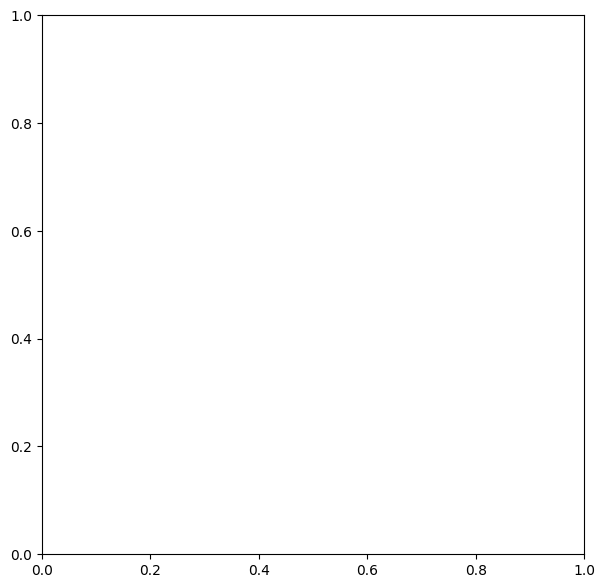

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.animation import FuncAnimation
import ipywidgets as widgets
from IPython.display import display

plt.ioff()
fig, ax = plt.subplots(figsize=(7, 7))
plt.ion()

slider_v_pies = widgets.FloatSlider(value=2.4, min=0.5, max=5.0, step=0.1, description='Velocity Dog:')
slider_v_krolik = widgets.FloatSlider(value=1.3, min=0.5, max=5.0, step=0.1, description='Velocity Rabbit:')
btn_run = widgets.Button(description='Run Simulation', button_style='success', icon='play')
ui = widgets.VBox([widgets.HBox([slider_v_pies, slider_v_krolik]), btn_run])

ani = None
#constans
def chase_simulation(b):
    global ani
    if ani is not None:
        try:
            ani.event_source.stop()
        except:
            pass
        del ani
        ani = None
    ax.clear() # Czyścimy poprzednią próbę
    
    # Pobieramy wartości ze sliderów
    V_DOG = slider_v_pies.value
    V_RABBIT = slider_v_krolik.value
    FRAMES = 300
    DT=0.1
    #set starting positions
    pos_rabbit_hole=np.array([0.0,0.0])
    pos_rabbit=np.array([12.0, 0.0])
    pos_dog=np.array([2.0, 10.0])
    #history of movement
    history_rabbit = [pos_rabbit.copy()]
    history_dog = [pos_dog.copy()]
    curr_rabbit = pos_rabbit.copy()
    curr_dog = pos_dog.copy()
    rabbit_in_hole = False
    dog_ate_rabbit = False
    #movement
    for _ in range(FRAMES):
        if not rabbit_in_hole and not dog_ate_rabbit:
            vector_to_hole = pos_rabbit_hole - curr_rabbit
            distance_to_hole = np.linalg.norm(vector_to_hole)
            if distance_to_hole < 0.1:
                # rabbit home:)
                vel_rabbit = np.array([0.0, 0.0])
                rabbit_in_hole = True
            else:
                direction = np.sign(pos_rabbit_hole[0] - curr_rabbit[0])#rabbit moves only on x axis
                vel_rabbit = np.array([direction * V_RABBIT, 0.0])
        if not rabbit_in_hole and not dog_ate_rabbit:
            vector_dog_rabbit = curr_rabbit - curr_dog
            distance_dog_rabbit = np.linalg.norm(vector_dog_rabbit)
            if distance_dog_rabbit < 0.2:
                vel_dog = np.array([0.0, 0.0])
                vel_rabbit = np.array([0.0,0.0])
                dog_ate_rabbit = True
            else:
                direction = vector_dog_rabbit / distance_dog_rabbit
                vel_dog = direction * V_DOG
        if not rabbit_in_hole and not dog_ate_rabbit:
            curr_rabbit += vel_rabbit*DT
            curr_dog  += vel_dog*DT
            history_rabbit.append(curr_rabbit.copy())
            history_dog.append(curr_dog.copy())
    history_rabbit = np.array(history_rabbit)
    history_dog = np.array(history_dog)
    #chart
    ax.set_title("Simulation of a chase between a dog and a rabbit")
    ax.set_xlim(-2, 14)
    ax.set_ylim(-2, 14)
    ax.set_aspect('equal')
    ax.grid(True, linestyle=':', alpha=0.6)
    
    ax.plot(0, 0, 'ko', markersize=15, markerfacecolor='black', label='Rabbit Hole')
    line_connector, = ax.plot([], [], 'k--', linewidth=1, alpha=0.4, label='Line of sight')
    dog_trace, = ax.plot([], [], 'c-', linewidth=1.5, alpha=0.2, label='Dog Trace')
    rabbit_dot, = ax.plot([], [], 'om', markersize=8, label='Rabbit', zorder=3)
    dog_dot, = ax.plot([], [], 'oc', markersize=10, label='Dog', zorder=3)
    ax.legend(loc='upper right')
    #animation
    def animate(i):
        idx = min(i, len(history_rabbit) - 1)
        rabbit_dot.set_data([history_rabbit[idx, 0]], [history_rabbit[idx, 1]])
        dog_dot.set_data([history_dog[idx, 0]], [history_dog[idx, 1]])
        line_connector.set_data([history_dog[idx, 0], history_rabbit[idx, 0]], [history_dog[idx, 1], history_rabbit[idx, 1]])
        dog_trace.set_data(history_dog[:idx+1, 0], history_dog[:idx+1, 1])
        return rabbit_dot, dog_dot, line_connector, dog_trace
    
    ani = FuncAnimation(fig, animate, frames=len(history_rabbit), interval=30, blit=True, repeat=False)
    fig.canvas.draw_idle()

btn_run.on_click(chase_simulation)

display(ui)
display(fig.canvas)

# 3. Porównanie metod numerycznych
# Opis
Porównujemy metodę Eulera oraz metodę Rungego-Kutty dla układu, gdzie uciekający (cel) porusza się jedynie po osi X. Krzywe przedstawiają tor ruchu ścigającego. <sup>[[3]](#bibliografia_2)</sup>

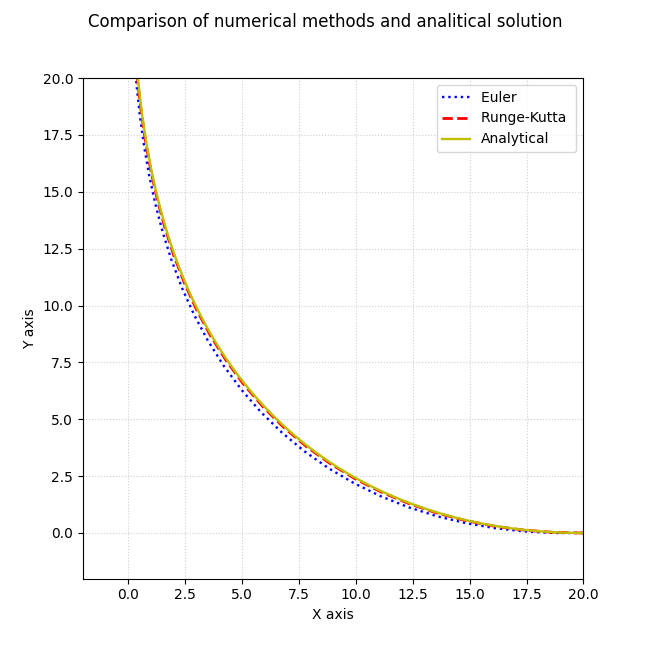

In [14]:
%matplotlib widget
import matplotlib.pyplot as plt
import numpy as np
import math
from matplotlib.animation import FuncAnimation
plt.close('all')
#constans

TIME_SPAN = (0, 25)
T_EVAL = np.linspace(TIME_SPAN[0],TIME_SPAN[1], 2000)
starting_pos = [20,0]
starting_pos_target = [0.0,0.0]
def target(t):
    return np.array([starting_pos_target[0],starting_pos_target[1]+t])#ruch jednostajny

def dynamics(t, pos):
    curr_pos = np.array([pos[0], pos[1]])
    curr_target = target(t)
    distance_to_target=np.linalg.norm(curr_target - curr_pos)
    if distance_to_target < 1e-5: return np.array([0.0, 0.0])#target caught
    unit_vector = (curr_target - curr_pos) / distance_to_target #dx/dt=V*(x_lion-x_target)/(distance); same with y:this is our differential equation
    return 1.3*unit_vector
#euler method
def euler_method(dynamics,time_span, y0,dt):#y0 is our initial condition
    time_values=[time_span[0]]
    y_values=[np.array(y0)]#list to save our steps
    t=time_span[0]
    y=np.array(y0)
    while t<time_span[1]:
        dydt=np.array(dynamics(t, y))#our derivative is equal to what we calculated in lion dynamics
        y=y+dt*dydt#step
        t+=dt
        y_values.append(y.copy())
        time_values.append(t)
    return np.array(time_values), np.array(y_values).T

#rungego-kutty method
def runge_kutty_method(dynamics,time_span,y0,h):
    time_values=[time_span[0]]
    y_values=[np.array(y0)]
    t=time_span[0]
    y=np.array(y0)
    while t<time_span[1]:
        a=np.array(dynamics(t, y))
        b=np.array(dynamics(t+(h/2), y+(h/2)*a))
        c=np.array(dynamics(t+(h/2), y+(h/2)*b))
        d=np.array(dynamics(t+(h/2), y+(h/2)*c))
        y=y+ (h/6)*(a+2*b+2*c+d)
        t+=h
        y_values.append(y.copy())
        time_values.append(t)
    return np.array(time_values), np.array(y_values).T
#analitical
def analitical(x_values):
    y_values=[]
    k=1/1.3#v_target/v_persuer
    a=20 #starting distance
    part1=((x_values/a)**(1+k))/(1+k)
    part2=((x_values/a)**(1-k))/(1-k)
    C=a*k/(1-k**2)# constant C = a*k/(1-k^2)
    y_values=(a/2)*(part1-part2)+C
    return y_values, x_values
#movement
DT=1
time_E, y_E=euler_method(dynamics,TIME_SPAN, starting_pos, DT)#we get steps in time and coordiates
time_R, y_R=runge_kutty_method(dynamics,TIME_SPAN, starting_pos, DT)
x_values=np.linspace(20, 0.01, 100) 
y_A, x_A=analitical(x_values)
fig, ax = plt.subplots(figsize=(6.5, 6.5))
fig.suptitle("Comparison of numerical methods and analitical solution")
ax.set_xlim(-2, 20)
ax.set_ylim(-2, 20)
ax.set_aspect('equal')
ax.grid(True, linestyle=':', alpha=0.6)
ax.set_xlabel("X axis")
ax.set_ylabel("Y axis")
ax.plot(y_E[0], y_E[1], 'b:', label='Euler ',linewidth=1.7)#euler
ax.plot(y_R[0], y_R[1], 'r--', label='Runge-Kutta ',linewidth=2)#runge-kutty
ax.plot(x_A, y_A, 'y-', label='Analytical', linewidth=1.7)#analitical
ax.legend(loc='upper right')
plt.show()

## Wnioski
Metoda Eulera wymaga od nas mniej obliczeń w porównaniu z metodą Rungego-Kutty - wykonujemy w każdym kroku aż 4 działania. Jednak jest ona dokładniejsza, szczególnie przy małych krokach (w kodzie DT). Błąd lokalny w metodzie Eulera się kumuluje, więc im dłużej trwa pościg, tym większa rozbieżność między rozwiązaniem analitycznym a obliczonym przy pomocy tej metody numerycznej.

# 4. Wyprowadzenie równania krzywej pogoni - problem pościgu liniowego<sup>[[4]](#bibliografia_4)</sup>
## Wprowadzenie

Rozpatrujemy klasyczny problem krzywej pogoni. Punkt *ścigający* porusza się po krzywej opisanej równaniem
$$
x = x(y), \quad x > 0,
$$
zaś punkt *ścigany* w każdej chwili znajduje się na stycznej do tej krzywej w aktualnym położeniu punktu ścigającego.
## Zależność geometryczna

Nachylenie stycznej do krzywej $x(y)$ w punkcie $(x,y)$ dane jest przez pochodną
$$
\frac{dx}{dy} = x'(y).
$$

Z geometrii układu (podobieństwo trójkątów oraz kierunek ruchu) otrzymujemy:
$$
\frac{dx}{dy} = -\frac{x}{a-y}.
$$

Znak minus uwzględnia fakt, że wraz ze wzrostem $y$ wartość $x$ maleje.

Po przekształceniu:
$$
(a-y)\frac{dx}{dy} = -x
$$
$$
(a-y)x' + x = 0.
$$
## Zależność czasowa

Zakładamy, że punkt ścigany porusza się ruchem jednostajnym z prędkością $v$, zatem
$$
a = vt.
$$

Z poprzedniego równania wynika:
$$
y = vt + \frac{x}{x'}.
$$

Różniczkując względem czasu $t$:
$$
y' = v + \frac{d}{dt}\left(\frac{x}{x'}\right).
$$

Ponieważ $x = x(y)$, stosujemy regułę łańcuchową:
$$
\frac{d}{dt}\left(\frac{x}{x'}\right)
=
\frac{d}{dy}\left(\frac{x}{x'}\right)y'.
$$

Obliczając pochodną ilorazu:
$$
\frac{d}{dy}\left(\frac{x}{x'}\right)
=
\frac{(x')^2 - x x''}{(x')^2}.
$$

Ostatecznie:
$$
y'
=
v + \frac{(x')^2 - x x''}{(x')^2}y'
$$
$$
y'\frac{x x''}{(x')^2} = v
$$
$$
y' = v\frac{(x')^2}{x x''}.
$$
## Warunek stałej prędkości

Niech punkt ścigający porusza się z prędkością stałą $w$:
$$
(dx)^2 + (dy)^2 = w^2(dt)^2.
$$

Dzieląc przez $(dt)^2$ oraz korzystając z $x' = x'y'$:
$$
(x'y')^2 + (y')^2 = w^2
$$
$$
(y')^2(1+x'^2) = w^2
$$
$$
y' = \frac{w}{\sqrt{1+x'^2}}.
$$
## Równanie różniczkowe toru

Porównując oba wyrażenia na $y'$:
$$
v\frac{(x')^2}{x x''} = \frac{w}{\sqrt{1+x'^2}}.
$$

Wprowadzamy stałą:
$$
k = \frac{w}{v}.
$$

Otrzymujemy równanie różniczkowe drugiego rzędu:
$$
x'' - k\frac{x'^2}{x(1+x'^2)} = 0.
$$
## Podstawienie upraszczające

Wprowadzamy podstawienie:
$$
u = y' = \frac{1}{x'},
$$
czyli
$$
x' = \frac{1}{u}, \quad x'' = -\frac{1}{u^3}\frac{du}{dx}.
$$

Po podstawieniu:
$$
-\frac{du}{dx} - k\frac{u}{x(1+u^2)} = 0
$$
$$
\frac{du}{1+u^2} = -k\frac{dx}{x}.
$$
## Całkowanie

Całkując obustronnie:
$$
\int \frac{du}{1+u^2} = -k\int\frac{dx}{x}
$$
$$
\arctan u = k\ln x + C.
$$

Stąd:
$$
u = \tan(k\ln x + C),
$$
czyli
$$
y' = \frac12\left[(C_1x)^k - (C_1x)^{-k}\right].
$$
## Drugie całkowanie

Dla $k \neq 1$:
$$
y(x) = \frac12\left(\frac{x^{1+k}}{1+k} - \frac{x^{1-k}}{1-k}\right) + C_2.
$$

Dla $k = 1$:
$$
y(x) = \frac12\left(\frac{x^2}{2} - \ln|x|\right) + C_2.
$$
## Warunki brzegowe

Z warunków:
$$
y'(1)=0, \quad y(1)=0
$$
wynika:
$$
C_1 = 1.
$$

oraz:
$$
C_2 = \frac{k}{1-k^2} \quad (k \neq 1),
\qquad
C_2 = -\frac14 \quad (k=1).
$$
## Ostateczna postać rozwiązania

Dla $k \neq 1$:
$$
y(x) = \frac12\left(\frac{x^{1+k}}{1+k} - \frac{x^{1-k}}{1-k}\right)
+ \frac{k}{1-k^2}.
$$

Dla $k = 1$:
$$
y(x) = \frac12\left(\frac{x^2}{2} - \ln|x|\right) - \frac14.
$$
## Uwaga końcowa

Postać odwrotna $x(y)$ również daje się wyrazić za pomocą funkcji elementarnych,
co kończy analizę krzywej pogoni.

# 5. Dodatkowe parametry - współczynnik zmęczenia
## Standardowy warunek pościgu

Bez zmęczenia mieliśmy klasyczny warunek:

$$
\frac{d\mathbf{r}_g}{dt} = \mathbf{r}_u - \mathbf{r}_g
$$

czyli wektor prędkości goniącego zawsze kieruje się na uciekającego, a prędkość jest stała:

$$
v_g = \text{const}.
$$
## Wprowadzenie współczynnika zmęczenia

Załóżmy, że goniący traci prędkość w czasie. Najprostszy model:

$$
v_g(t) = v_0 \cdot f(t)
$$

gdzie $f(t)$ opisuje spadek prędkości. Typowe funkcje $f(t)$:

- **Liniowa utrata siły**:  
$$
f(t) = 1 - \alpha t, \quad \alpha > 0
$$

- **Wykładnicza utrata siły** (popularne w modelach fizjologicznych):  
$$
f(t) = e^{-\alpha t}
$$

## Efekt zmęczenia

- Jeśli goniący prędkość traci zbyt szybko, może nigdy nie dogonić celu.  
- Tor goniącego staje się bardziej „wygięty” w kierunku uciekającego,  
  ale jego długość rośnie, bo goniący „wolniej dociera” do celu.  
- W modelu wykładniczym tor asymptotycznie może nawet nie dotknąć celu,  
  jeśli uciekający ma stałą prędkość.

# 6. Przykład "Lew i gazele"
## Opis problemu
Przykład ten stanowi rozbudowaną wersję klasycznej krzywej pościgu. Wprowadza elementy ograniczeń biologicznych oraz liczebność ściganych. Model jest bardziej realistyczny dzięki uwzględnieniu następujących aspektów:
*  <b>Liczebność ściganych</b>: wprowadzamy dwie gazele, symulujemy naturalne warunki, gdzie drapieżnik musi podjąć decyzję o celu.
*  <b>Zygzakowaty tor</b>: ruch gazel opisany jest za pomocą funkcji okresowych, jest to rzeczywisty mechanizm obronny mający na celu zmylenie drapieżnika.
*  <b>Model zmęczenia</b>: szybkość zwierząt nie jest stała, poruszają się one ruchem jednostajnie opóźnionym - ich prędkość maleje wykładniczo. Współczynnik zmęczenia lwa jest większy niż gazeli, aby jak najlepiej odzwierciedlić prawdziwe warunki.
*  <b>Dynamiczny wybór celu</b>: lew goni gazele znajdującą się najbliżej, aby pogoń była najbardziej optymalna - możliwa jest nagła zmiana kierunku.
## Wzór na kierunek ruchu lwa
 $$\vec{v} = V_{P}\frac{\vec{R}_{T}-\vec{R}_{p}}{\left\|{\vec{R}_{T}-\vec{R}_{p}}\right\|}$$ Gdzie: 
 * $\vec{v}$ - prędkość lwa,
 * $V_{P}$ - szybkość lwa,
 * $\vec{R}_{T}=\left[x_{T}, y_{T}\right]$- położenie gazeli,
 * $\vec{R}_{P}=\left[x_{P}, y_{P}\right]$ - położenie lwa,
## Jak opisać ruch lwa?
$\vec{v}=\left[\frac{d x_P}{d t}, \frac{d y_P}{d t}\right]$ - prędkość to pochodna po czasie położenia, więc przedstawiamy ją jako układ dwóch równań różniczkowych pierwszego rzędu
$$
\begin{cases} 
\frac{dx_P}{dt} = V_{P}\frac{x_{T} - x_{P}}{\sqrt{(x_T - x_P)^2 + (y_T - y_p)^2}} \\ 
\frac{dy_P}{dt} = V_{P}\frac{y_{T} - y_{P}}{\sqrt{(x_T - x_P)^2 + (y_T - y_P)^2}}
\end{cases}
$$
## Model zmęczenia
Szybkość zwierząt maleje liniowo wraz z upływem czasu:
* <b>Szybkość lwa</b>: $V_P(t)=\max(0;V_P(0)-k_P\cdot t)$
* <b>Szybkość gazel</b>: $V_P(t)=\max(0;V_T(0)-k_T\cdot t)$
<br>$k_P>k_T$,  ponieważ, zgodnie z założeniami, lew męczy się szybciej od gazel
## Metoda Eulera
Problem jest rozwiązany metodą Eulera. Aby wyznaczyć tor ruchu lwa, przybliżamy rozwiązanie układu równań różniczkowych w skończonych (ustalonych) krokach czasowych równych $\Delta t$:
$$x_{P, n+1}=x_{P, n}+\frac{d x_P}{d t} \cdot \Delta t$$
$$y_{P, n+1}=y_{P, n}+\frac{d y_P}{d t} \cdot \Delta t$$
## Symulacja w Pythonie


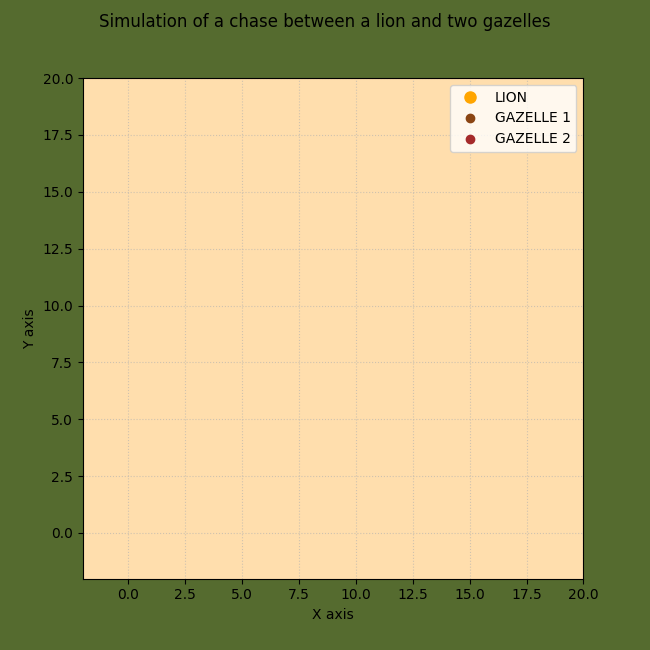

In [3]:
%matplotlib widget
import matplotlib.pyplot as plt
import numpy as np
import math
from matplotlib.animation import FuncAnimation
plt.close('all')
#constans
V_GAZELLE=0.9#90km/h, speed gazelle starts with
AMPLITUDE = 3
FREQUENCY = 0.5
K_GAZELLE=0.01#stamina
V_LION=1.5#80km/h, speed lion gazelle starts with
K_LION=0.02#lion gets tired quicker/loses speed faster
TIME_SPAN = (0, 25)
T_EVAL = np.linspace(TIME_SPAN[0],TIME_SPAN[1], 2000)

#set starting positions
pos_gazelle1_start=np.array([9, 0.5])
pos_gazelle2_start=np.array([11, 0.5])
pos_lion_start=np.array([10, 0])

#animal speeds
def get_speeds(t):
    v_l = np.maximum(0, (V_LION) - (math.exp(-1*K_LION*t)))#exponential loss of strength
    v_g = np.maximum(0, (V_GAZELLE) - (math.exp(-1*K_GAZELLE*t)))
    return v_l, v_g

#functions defining gazzeles movements
def gazelle1_pos(t):
    dist = V_GAZELLE * t - 0.5 * K_GAZELLE * t**2 #distance during uniformly decelerated motion
    return np.array([pos_gazelle1_start[0] + AMPLITUDE * np.sin(FREQUENCY * t), pos_gazelle1_start[1] + dist ])

def gazelle2_pos(t):
    dist = V_GAZELLE * t - 0.5 * K_GAZELLE * t**2 #distance during uniformly decelerated motion
    return np.array([pos_gazelle2_start[0] - AMPLITUDE * np.sin(FREQUENCY * t), pos_gazelle2_start[1] + dist])

#lion
def lion_dynamics(t, pos):
    lion_pos = np.array([pos[0], pos[1]])
    v_lion_curr, _ = get_speeds(t) #we get both speeds (lion and gazzele), but we only need lion's
    if v_lion_curr <= 0: return [0, 0]#lion got tired and stopped
    g1 = gazelle1_pos(t)
    g2 = gazelle2_pos(t)
    distance_lion_gazelle1=np.linalg.norm(g1 - lion_pos)#calculation the distance between lion and each gazelle to determin which to pursuit
    distance_lion_gazelle2=np.linalg.norm(g2 - lion_pos)
    target = g1 if distance_lion_gazelle1 < distance_lion_gazelle2 else g2
    dist_to_target = np.linalg.norm(target - lion_pos) #denominator in our differential equation
    if dist_to_target < 0.05: #lion ate gazelle
        return [0, 0]
    unit_vector = (target - lion_pos) / dist_to_target #dx/dt=V*(x_lion-x_target)/(distance); same with y:this is our differential equation
    v_vector = unit_vector * v_lion_curr#current speed
    return [v_vector[0], v_vector[1]]#derevatives with respect to t

def catch_event(t, pos):#lion caught gazelle
    lion_pos = np.array([pos[0], pos[1]])
    dist = min(np.linalg.norm(gazelle1_pos(t) - lion_pos), 
               np.linalg.norm(gazelle2_pos(t) - lion_pos))
    return dist - 0.1
catch_event.terminal = True

def fatigue_event(t, pos):#lion stopped
    v_l, _ = get_speeds(t)
    return v_l - 0.01 
fatigue_event.terminal = True

def euler_method(dynamics,time_span, y0,dt):#y0 is our initial condition
    time_values=[time_span[0]]
    y_values=[np.array(y0)]#list to save our steps
    t=time_span[0]
    y=np.array(y0)
    while t<time_span[1]:
        dydt=np.array(dynamics(t, y))#our derivative is equal to what we calculated in lion dynamics
        y=y+dt*dydt#step
        t=t+dt
        y_values.append(y.copy())
        time_values.append(t)
        v_lion_curr, _ = get_speeds(t)
        if v_lion_curr<0.1:
            print("lion gave up")
            break
        g1_dist = np.linalg.norm(gazelle1_pos(t) - y)
        g2_dist = np.linalg.norm(gazelle2_pos(t) - y)
        if min(g1_dist,g2_dist)<0.1:
            print("lion ate gazelle")
            break
    return np.array(time_values), np.array(y_values).T


#movement
DT=0.01
time, y = euler_method(lion_dynamics,TIME_SPAN, pos_lion_start, DT)#we get steps in time and coordiates
lion_x, lion_y = y#lion coordinates
g1_traj = np.array([gazelle1_pos(t) for t in time])#trajectory of gazelles in calculated times in the euler method
g2_traj = np.array([gazelle2_pos(t) for t in time])

#chart
fig, ax = plt.subplots(figsize=(6.5, 6.5))
fig.suptitle("Simulation of a chase between a lion and two gazelles")
fig.patch.set_facecolor('darkolivegreen')
ax.set_facecolor('navajowhite')
ax.set_xlim(-2, 20)
ax.set_ylim(-2, 20)
ax.set_aspect('equal')
ax.grid(True, linestyle=':', alpha=0.6)
ax.set_xlabel("X axis")
ax.set_ylabel("Y axis")
line_l, = ax.plot([], [], 'orange', alpha=0.3)  #lion track
line_g1, = ax.plot([], [], 'saddlebrown', alpha=0.3) #gazelle 1 track
line_g2, = ax.plot([], [], 'brown', alpha=0.3) #gazelle 2 track
dot_l, = ax.plot([], [], 'o', color='orange', label='LION', markersize=8) #current lion position
dot_g1, = ax.plot([], [], 'o', color='saddlebrown', label='GAZELLE 1')#current gazelle 1 position
dot_g2, = ax.plot([], [], 'o', color='brown', label='GAZELLE 2')#current gazelle 2 position
ax.legend(loc='upper right')
status_text = ax.text(0.05, 0.95, '',transform=ax.transAxes,fontsize=12,fontweight='bold',verticalalignment='top',bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
final_time=time[-1]#calculating why the chase stopped; did lion get tired or did gazelles get eaten
final_lion_pos=y[:,-1]
lion_final_speed,_=get_speeds(final_time)
dist1 = np.linalg.norm(gazelle1_pos(final_time) - final_lion_pos)
dist2 = np.linalg.norm(gazelle2_pos(final_time) - final_lion_pos)
if min(dist1, dist2) < 0.15:
    outcome = "LION ATE GAZELLE"
    outcome_color = 'red'
elif lion_final_speed < 0.05:
    outcome = "LION GOT TIRED"
    outcome_color = 'blue'
else:
    outcome = "GAZELLES ESCAPED"
    outcome_color = 'black'

#animation
skip = 5 
frame_indices = np.arange(0, len(time), 10)
if frame_indices[-1] != len(time) - 1:
    frame_indices = np.append(frame_indices, len(time) - 1)
def animate(frame):
    dot_l.set_data([lion_x[frame]], [lion_y[frame]])
    dot_g1.set_data([g1_traj[frame, 0]], [g1_traj[frame, 1]])
    dot_g2.set_data([g2_traj[frame, 0]], [g2_traj[frame, 1]])
    
    line_l.set_data(lion_x[:frame], lion_y[:frame])
    line_g1.set_data(g1_traj[:frame,0], g1_traj[:frame,1])
    line_g2.set_data(g2_traj[:frame,0], g2_traj[:frame,1])
    if frame == frame_indices[-1]:#last frame so we show why the animation stopped
        status_text.set_text(outcome)
        status_text.set_color(outcome_color)
    return dot_l, dot_g1, dot_g2, line_l, line_g1, line_g2, status_text
ani_lion = FuncAnimation(fig, animate, frames=frame_indices, interval=30, blit=True, repeat=False)
ani_lion

## Wnioski 
* <b>Okno czasowe</b>: Lew męczy się znacznie szybciej niż gazela, więc sukces pościgu możliwy jest jedynie w początkowej fazie. Po pewnym czasie porażka będzie już nieunikniona.
* <b>Tor zygzakowaty</b>: Gazela, poruszając się po zygzakowatym torze, pokonuje znacznie dłuższą drogę niż lew ścinający zakręty.
* <b>Krok czasowy</b>: Jego wartość wpływa na wynik naszego przybliżenia. Przy dużych krokach gwałtowne zmiany ruchu gazeli mogą powodować błędy numeryczne, co przyczyni się do powstania wykresów, które błędnie odzwierciedlają rzeczywisty problem. 

# 7. Przykład "Miasto, samolot, rakieta"<sup>[[5]](#bibliografia_5)</sup>
## Scenariusz pościgu w 2D
Analizę złożonych układów warto poprzedzić badaniem podstawowego przypadku 2D.W tej sekcji wyprowadzę
równanie krzywej pościgu dla klasycznego problemu Pierre’a Bouguera <sup>[[6]](#bibliografia_6)</sup> (1732). Rozważymy model pościgu jeden na jeden,
w którym obiekt uciekający porusza się po linii prostej równoległej do osi $y$.
## Opis

Aby opisać ten problem, możemy użyć przykładu rakiety i samolotu, gdzie rakieta jest
ścigającym, a samolot obiektem ściganym. Tylko wtedy, gdy samolot znajduje się wewnątrz kwadratu
o boku długości \(R\), rakieta może go zlokalizować i dosięgnąć.
Początkowe położenia różnych obiektów są następujące:

- **Samolot:** prawy dolny róg.
- **Miasto A:** prawy górny róg, dokładnie nad samolotem.  
  Zatem samolot będzie poruszał się tylko pionowo.
- **Rakieta:** lewy dolny róg, obok samolotu i w przeciwległym rogu względem miasta.

Z tych położeń możemy wywnioskować, że odległość od rakiety do miasta A jest równa odległości
od samolotu do miasta A, co można zobaczyć na Diagramie<sup>[[7]](#bibliografia_7)</sup>, który pokazuje również początkowe
położenia rakiety, samolotu i miasta A.
<img src="diagramkwadrat.png" alt="Diagram1" width="800" style="float: left;">
Celem tego problemu jest po pierwsze wyznaczenie równania krzywej, która symuluje
najkrótszą drogę, jaką rakieta musiałaby przebyć, aby dotrzeć do samolotu, a po drugie
sprawdzenie, czy rakieta będzie w stanie dosięgnąć samolotu w zadanym obszarze kwadratu
o boku długości $R$, przy założeniu, że znane są prędkości zarówno samolotu, jak i rakiety.
Innymi słowy, interesuje nas, czy rakieta zdąży dosięgnąć samolotu, zanim ten zacznie
bombardować Miasto A.
## Obliczenia
<details>
  <summary>👉 <b>Równanie 1</b></summary>

Położenie samolotu w chwili $t = 0$ wynosi $(R, 0)$.  
Ponieważ samolot porusza się zawsze wzdłuż prostej $x = R$ ze stałą prędkością $V_p$,  
to dla $t > 0$ jego współrzędne będą równe:

$$
(x_p(t), y_p(t)) = (R, V_p t).
$$

Położenie rakiety w chwili $t = 0$ wynosi $(0, 0)$.  
Ponieważ rakieta nie porusza się po linii prostej, jej współrzędne zmieniają się w czasie:

$$
(x(t), y(t)).
$$

Znając te dwa punkty, nachylenie stycznej do krzywej pościgu w punkcie $(x, y)$  
można wyrazić równaniem (1):

$$
\frac{dy}{dx} = \frac{V_p t - y}{R - x}
$$
**(Równanie 1)**
   
To obliczenie jest dodatkowo wyjaśnione na poniższym Diagramie wektorowym<sup>[[8]](#bibliografia_8)</sup>,  
gdzie zielony wektor jest styczną do krzywej pościgu w punkcie $(x, y)$:

<img src="diagramwektory.png" alt="Diagram-wektory" width="300" style="float: left;">


*Legenda:*  
- **Zielony wektor** – styczna do krzywej pościgu w punkcie $(x, y)$  
- **Czerwony punkt** – położenie rakiety w danym momencie  
- **Niebieski punkt** – położenie samolotu
    
</details>
<details>
  <summary>👉 <b>Równanie 2</b></summary>
Jeśli przekształcimy równanie (1), aby wyznaczyć z niego $t$, otrzymamy:

$$
t = \frac{\frac{dy}{dx} \,(R - x)}{V_p} + \frac{y}{V_p}
$$

Dodatkowo wiemy, że rakieta w każdej chwili przebyła drogę równą $V_m \cdot t$ (gdzie $V_m$ odpowiada prędkości pocisku/rakiety) wzdłuż krzywej pościgu.  
Korzystając ze wzoru na długość łuku:

$$
V_m t = \int_0^t \sqrt{ 1 + \left(\frac{dy}{dx}\right)^2} \, dx
$$

Teraz przekształcamy powyższe równanie tak, aby $t$ było po lewej stronie:

$$
t = \frac{1}{V_m} \int_{0}^{x} \sqrt{1 + \left( \frac{dy}{dx} \right)^2} \, dx
$$

Ponieważ przekształcone równanie na długość łuku oraz nachylenie stycznej w punkcie $(x, y)$ są równe $t$, możemy je teraz ze sobą zrównać:

$$
\frac{1}{V_m} \int_{0}^{x} \sqrt{1 + \left( \frac{dy}{dx} \right)^2} \, dx
=
\frac{\frac{dy}{dx} \,(R - x)}{V_p} + \frac{y}{V_p}
$$

Zróżniczkowanie obu stron pozwoli usunąć całkę. Najpierw musimy użyć różniczkowania niejawnego oraz zastosować regułę iloczynu:

$$
\frac{1}{V_m} \sqrt{1 + h(x)^2}
=
\frac{R - x}{V_p} \frac{dh}{dx} + \frac{1}{V_p} \frac{dy}{dx} - \frac{h(x)}{V_p}
$$

Możemy teraz zastąpić $\frac{dy}{dx}$ przez $h(x)$, co pozwala nam uprościć równanie:

$$
\frac{1}{V_m} \sqrt{1 + (h(x))^2} = \frac{R - x}{V_p} \frac{dh}{dx}
$$

Mnożymy obie strony przez $V_p$:

$$
\frac{1}{n} \sqrt{1 + (h(x))^2} = (R - x) \frac{dh}{dx}
$$
**(Równanie 2)**  

</details>
<details>
  <summary>👉 <b>Równanie 3</b></summary>
Gdzie $V_M \neq 0$ oraz $V_P \neq 0$, ponieważ żadna z tych prędkości nie może być równa zeru.  
Wektory prędkości są zawsze skierowane w tą samą stronę, co oznacza, że mają ten sam znak — albo oba dodatnie, albo oba ujemne — a więc:

$$
\frac{V_M}{V_P} > 0
$$

Jeśli teraz podstawimy $h(x)$ przez $h$ i przekształcimy równanie, otrzymamy równanie różniczkowe o zmiennych rozdzielonych, które możemy scałkować po obu stronach:

$$
\frac{dh}{\sqrt{1 + h^2}} = \frac{1}{n} \frac{dx}{R - x}
$$

- **Prawa strona (RHS):** Ponieważ $\frac{1}{n}$ jest stałą, możemy ją wyłączyć przed całkę:

$$
\int \frac{1}{n} \frac{dx}{R - x} = \frac{1}{n} \int \frac{1}{R - x} \, dx
$$

Całkę rozwiązujemy metodą podstawienia $u = R - x$:

$$
-\frac{1}{n} \int \frac{1}{u} \, du = -\frac{1}{n} \ln(R - x) + C
$$

- **Lewa strona (LHS):** Aby scałkować lewą stronę, stosujemy podstawienie $h = \tan(u)$, jeśli $h = \tan(u)$ to:

$$
\begin{aligned}
dh &= \sec^2(u) \, du \\
&= \int \frac{\sec^2(u) \, du}{\sqrt{\sec^2(u)}} \\
&= \int \frac{\sec^2(u) \, du}{\sec(u)} \\
&= \int \sec(u) \, du
\end{aligned}
$$
Aby rozwiązać tę całkę, możemy pomnożyć licznik i mianownik przez ten sam czynnik, co w praktyce nie zmienia wartości wyrażenia:

$$
\begin{aligned}
\int \sec(u) \, du \cdot \frac{\tan(u) + \sec(u)}{\tan(u) + \sec(u)}
&= \int \frac{\sec^2(u) + \sec(u)\tan(u)}{\tan(u) + \sec(u)} \, du
\end{aligned}
$$

Teraz możemy użyć podstawienia:

$$
t = \tan(u) + \sec(u), \quad dt = (\tan(u)\sec(u) + \sec^2(u)) \, du
$$

i otrzymujemy:

$$
\begin{aligned}
\int \frac{1}{t} \, dt &= \ln(t) + C \\
&= \ln(\tan(u) + \sec(u)) + C
\end{aligned}
$$

Możemy teraz przyrównać obie strony, otrzymując:

$$
\ln(\tan(u) + \sec(u)) + C = -\frac{1}{n} \ln(R - x) + C
$$

Ponieważ $\tan(u) = h$ i $\sec^2(u) = 1 + \tan^2(u)$, a więc $\sec(u) = \sqrt{1 + h^2}$, mamy:

$$
\ln\big(\sqrt{1 + h^2} + h\big) + C = -\frac{1}{n} \ln(R - x)
$$

Chociaż rozwiązaliśmy całkę nieoznaczoną, aby znaleźć równanie krzywej pościgu, musimy jeszcze wyznaczyć stałą całkowania $C$.  
Aby to zrobić, możemy użyć punktu $(0,0)$ dla chwili $t=0$. Przypominamy, że $h = y'$, oraz że dla $t=0$, $h = 0$:

$$
\ln\big(\sqrt{1 + 0^2} + 0\big) + C = -\frac{1}{n} \ln(R - 0)
\quad \Rightarrow \quad
\ln(1) + C = -\frac{1}{n} \ln(R)
\quad \Rightarrow \quad
C = -\frac{1}{n} \ln(R)
$$
Możemy podstawić $C$ i przekształcić równanie, korzystając z własności logarytmu:

$$
\begin{aligned}
\sqrt{1 + h^2} + h - \frac{1}{n} \ln R &= - \frac{1}{n} \ln (R - x) \\
\sqrt{1 + h^2} + h - \frac{1}{n} \ln R + \frac{1}{n} \ln (R - x) &= 0 \\
\ln \Big[ \left( \sqrt{1 + h^2} + h \right) \left( 1 - \frac{x}{R} \right)^{1/n} \Big] &= 0
\end{aligned}
$$

Jeśli $\ln(x) = 0$, to $x = 1$, zatem:

$$
\left( \sqrt{1 + h^2} + h \right) \left( 1 - \frac{x}{R} \right)^{1/n} = 1
$$

Teraz rozwiązujemy równanie względem $h$, dzieląc obie strony:

$$
\sqrt{1 + h^2} + h = \left( 1 - \frac{x}{R} \right)^{-1/n}
$$

Wprowadzamy nową zmienną $p$:

$$
p = \left( 1 - \frac{x}{R} \right)^{-1/n}
$$

co upraszcza dalsze obliczenia:

$$
\begin{aligned}
h + \sqrt{1 + h^2} &= p \\
1 + h^2 &= (p - h)^2 \\
1 + h^2 &= p^2 - 2ph + h^2 \\
2ph &= p^2 - 1
\end{aligned}
$$

Rozwiązując równanie względem $h$, otrzymujemy:

$$
h = \frac{1}{2} \left( p - \frac{1}{p} \right)
$$

Teraz możemy podstawić $h$ i $p$ ich oryginalnymi zmiennymi:

$$
\frac{dy}{dx} = \frac{1}{2} \left[ \left( 1 - \frac{x}{R} \right)^{-1/n} - \left( 1 - \frac{x}{R} \right)^{1/n} \right]
$$

Całkujemy obie strony względem $x$:

$$
y(x) + C = \frac{1}{2} \int \left(1 - \frac{x}{R}\right)^{-1/n} dx
- \frac{1}{2} \int \left(1 - \frac{x}{R}\right)^{1/n} dx
$$

Po scałkowaniu otrzymujemy ostateczne rozwiązanie krzywej pościgu:

$$
y(x) + C = -\frac{1}{2} \frac{nR}{n - 1} \left(1 - \frac{x}{R}\right)^{1 - \frac{1}{n}}
+ \frac{1}{2} \frac{nR}{n + 1} \left(1 - \frac{x}{R}\right)^{1 + \frac{1}{n}}
$$

**(Równanie 3)**
</details>
<details>
  <summary>👉 <b>Równanie 4</b></summary>
Teraz musimy wyznaczyć stałą $C$, ponieważ wiemy, że rakieta startuje z punktu $(0, 0)$:

$$
C = -\frac{1}{2}\,\frac{nR}{n - 1} + \frac{1}{2}\,\frac{nR}{n + 1}
= \frac{1}{2} nR \left( \frac{1}{n + 1} - \frac{1}{n - 1} \right)
$$

$$
C = \frac{1}{2} nR \left( \frac{2}{n^2 - 1} \right) = \frac{nR}{n^2 - 1}
$$

Teraz możemy przekształcić równanie i podstawić $C$ do równania (3):

$$
y(x) = \frac{1}{2}\,\frac{nR}{n + 1}\left(1 - \frac{x}{R}\right)^{1 + \frac{1}{n}}
- \frac{1}{2}\,\frac{nR}{n - 1}\left(1 - \frac{x}{R}\right)^{1 - \frac{1}{n}}
+ \frac{nR}{n^2 - 1}
$$

**(Równanie 4)**

Gdzie $n = \frac{V_M}{V_P}$.
**Wykres funkcji:**
</details>

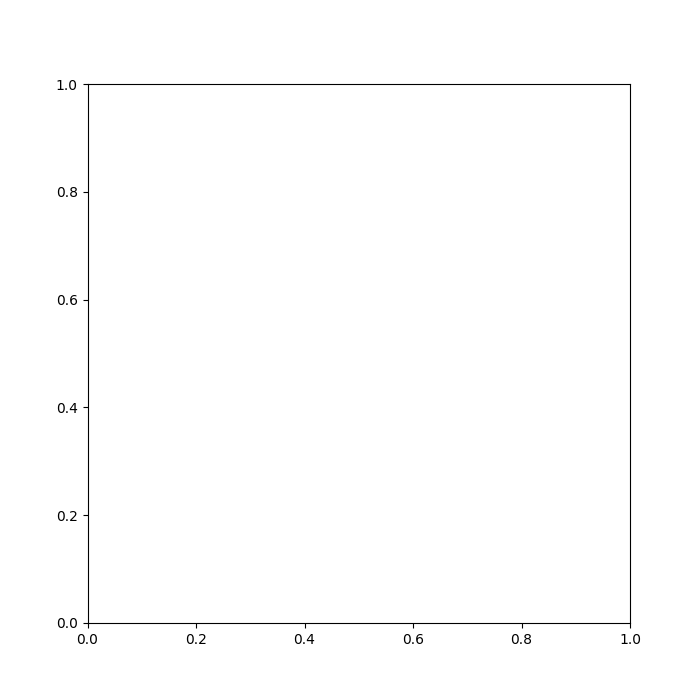

In [4]:
%matplotlib widget
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.animation import FuncAnimation
import ipywidgets as widgets
from IPython.display import display

plt.ioff()
fig, ax = plt.subplots(figsize=(7, 7))
plt.ion()

slider_v_rocket = widgets.FloatSlider(value=2.4, min=0.5, max=5.0, step=0.1, description='Velocity Rocket:')
slider_v_plane = widgets.FloatSlider(value=1.3, min=0.5, max=5.0, step=0.1, description='Velocity Plane:')
btn_run = widgets.Button(description='Run Simulation', button_style='success', icon='play')
ui = widgets.VBox([widgets.HBox([slider_v_rocket, slider_v_plane]), btn_run])

ani = None
#constans
def chase_simulation(b):
    global ani
    if ani is not None:
        try:
            ani.event_source.stop()
        except:
            pass
        del ani
        ani = None
    ax.clear() 
    
    V_ROCKET = slider_v_rocket.value
    V_PLANE = slider_v_plane.value
    FRAMES = 300
    DT=0.1
    #set starting positions
    pos_city=np.array([12,12])
    pos_plane=np.array([12.0, 0.0])
    pos_rocket=np.array([2.0, 10.0])
    #history of movement
    history_plane = [pos_plane.copy()]
    history_rocket = [pos_rocket.copy()]
    curr_plane = pos_plane.copy()
    curr_rocket = pos_rocket.copy()
    plane_arrived = False
    rocket_hit_plane = False
    #movement - Euler Method
    for _ in range(FRAMES):
        vec_to_city = pos_city - curr_plane
        dist_to_city = np.linalg.norm(vec_to_city) 
        vec_to_plane = curr_plane - curr_rocket
        dist_to_plane = np.linalg.norm(vec_to_plane)
        if dist_to_plane < 0.3:
            status = "Rocket hit plane!"
            break
        if dist_to_city < 0.2:
            status = "Plane arrived!"
            break
        vel_plane = (vec_to_city / dist_to_city) * V_PLANE
        vel_rocket = (vec_to_plane / dist_to_plane) * V_ROCKET
        curr_plane += vel_plane * DT
        curr_rocket += vel_rocket * DT
        history_plane.append(curr_plane.copy())
        history_rocket.append(curr_rocket.copy())
    history_plane = np.array(history_plane)
    history_rocket = np.array(history_rocket)
    #chart
    ax.set_title("Simulation of a rocket chasing a plane")
    ax.set_xlim(-1, 15)
    ax.set_ylim(-1, 15)
    ax.set_aspect('equal')
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.set_facecolor('lightblue')
    ax.plot(pos_city[0], pos_city[1], 'ks', markersize=15, markerfacecolor='black', label='CITY')
    rocket_trace, = ax.plot([], [], 'r-', linewidth=1.5, alpha=0.2, label='Rocket Trace')
    plane_dot, = ax.plot([], [], 'bo', markersize=8, label='PLANE', zorder=3)
    rocket_dot, = ax.plot([], [], 'ro', markersize=10, label='ROCKET', zorder=3)
    ax.legend(loc='upper left')
    #animation
    def animate(i):
        idx = min(i, len(history_plane) - 1)
        plane_dot.set_data([history_plane[idx, 0]], [history_plane[idx, 1]])
        rocket_dot.set_data([history_rocket[idx, 0]], [history_rocket[idx, 1]])
        rocket_trace.set_data(history_rocket[:idx+1, 0], history_rocket[:idx+1, 1])
        return plane_dot, rocket_dot, rocket_trace
    
    ani = FuncAnimation(fig, animate, frames=len(history_plane), interval=30, blit=True, repeat=False)
    fig.canvas.draw()

btn_run.on_click(chase_simulation)

display(ui)
display(fig.canvas)

*Legenda:*  
- **Czerwona linia** – tor lotu rakiety  
- **Niebieska linia** – tor lotu samolotu  
- **Punkt przecięcia** – punkt zderzenia i położenie Miasta A
Dla przykładowych wartości $p$ i $R$:
$$
p = 1.6 \quad \text{oraz} \quad R = 10
$$

Zmienne $p$ i $R$ zatem decyduja o położeniu punkty zderzenia, a więc o tym rakieta zdąży dosięgnąć samolotu, zanim ten dotrze do Miasta A.
# Zmienne

## Zmienne $n$ i $R$ oraz ich znaczenie

Jak powiedzieliśmy wcześniej, $R$ to długość boku kwadratu,
w którym rakieta jest w stanie zlokalizować samolot. Kwadrat ten,
jak widać na Diagramie, ma swój prawy górny wierzchołek w punkcie,
gdzie znajduje się Miasto A.

Z drugiej strony zmienna $n$ ma znacznie więcej niuansów. Ponieważ
$$
n = \frac{V_M}{V_P},
$$
a zarówno $V_M$, jak i $V_P$ są stałe, to również $n$ musi być stałe.

Możemy uogólnić wyniki dla różnych wartości $n$ do trzech głównych
scenariuszy, jak pokazano w tabeli poniżej:
| $n$       | Prędkości                              | Czy rakieta dogoni samolot na czas? | Wyjaśnienie |
|-----------|----------------------------------------|-----------------------------------|-------------|
| 1         | Prędkości są takie same                 | Nie                               | Ponieważ odległość między rakietą a Miastem A jest większa niż odległość między samolotem a Miastem A, jeśli obie prędkości są takie same, rakieta nie będzie skracać dystansu do samolotu. |
| $n>1$     | Prędkość rakiety jest większa niż prędkość samolotu | Zależy                            | Jak zostanie to także wyjaśnione później w Tabeli 2, nawet jeśli prędkość rakiety jest większa niż prędkość samolotu, nie jest jeszcze pewne, że rakieta dotrze do Miasta A na czas. Dzieje się tak wtedy, gdy prędkość rakiety jest tylko nieznacznie większa od prędkości samolotu. |
| $0<n<1$   | Prędkość samolotu jest większa niż prędkość rakiety | Nie                               | Jeśli prędkość samolotu jest większa niż prędkość rakiety, odległość między nimi będzie z czasem rosnąć, więc rakieta nigdy nie przechwyci samolotu. |

**Tabela:** Scenariusze dla różnych wartości $n$ i ich wpływ na możliwość przechwycenia samolotu przez rakietę.
# Wyznaczanie współrzędnych punktu zderzenia przy danych wartościach $R$ i $n$

W równaniu (4) znaleźliśmy zależność między $n$ — stosunkiem prędkości —
a $R$ — długością boku kwadratu, w którym rakieta jest w stanie zlokalizować samolot —
oraz ich początkową odległością.

Ponieważ samolot porusza się zawsze wzdłuż linii $x = R$,
rakieta uderzy w samolot w punkcie $P$, którego współrzędna $x$
jest zawsze równa $R$. Pozwala to założyć, że punkt zderzenia $P$
będzie miał współrzędne $(R, y(R))$, co umożliwia podstawienie
$R$ w miejsce $x$ w równaniu (4), jak pokazano poniżej:

$$
y(R) = -\frac{1}{2}\left(\frac{nR}{n-1}\right)\left(1 - \frac{R}{R}\right)^{1 - \frac{1}{n}}
       + \frac{1}{2}\left(\frac{nR}{n+1}\right)\left(1 - \frac{R}{R}\right)^{1 + \frac{1}{n}}
       + \frac{nR}{n^2 - 1}
$$


Po uproszczeniu otrzymujemy:

$$
y(R) = -\frac{1}{2}\left(\frac{nR}{n-1}\right)\cdot 0 + \frac{1}{2}\left(\frac{nR}{n+1}\right)\cdot 0 + \frac{nR}{n^2 - 1}
$$
           
W związku z tym współrzędne punktu $P$ są równe $(R, y(R))$, gdzie

$$
y(R) = \frac{nR}{n^2 - 1}
$$

Jak widać z równania współrzędnej $y$ punktu $P$, istnieją pewne wartości $n$,
dla których rakieta nigdy nie przecina toru lotu samolotu,
co dodatkowo wyjaśnia informacje podane w Tabeli 1.
Wartości $n$, dla których powyższe wyrażenie jest nieokreślone, to
$n = \pm 1$. Jak wspomniano wcześniej, możemy wyeliminować przypadek
$n = -1$.

Można to także wytłumaczyć logicznie: tor lotu rakiety jest dłuższy
niż tor samolotu, więc jeśli $n = 1$, rakieta nigdy nie dosięgnie samolotu.

Samolot nie zostanie przechwycony przez rakietę, z wyjątkiem przypadku,
gdy $n = 0$, co oznacza, że oba obiekty startują dokładnie z tego samego
miejsca i w chwili $t = 0$ rakieta już dosięga samolotu.

# Analiza wartości $n$ przy początkowej odległości 20 km

Aby znaleźć, dla jakich wartości $n > 1$ rakieta nie trafi w samolot,
należy rozwiązać nierówność:
$$
\frac{nR}{n^2 - 1} < R
$$

Możemy przyjąć $R$ jako dowolną wartość, na przykład $20\ \text{km}$.
Wówczas otrzymujemy:
$$
\frac{20n}{n^2 - 1} < 20
$$

Korzystając z kalkulatora graficznego (GDC), możemy obliczyć przedziały:
$$
-1 < n < -0{,}61803, \quad 1 < n < 1{,}61803
$$

Możemy pominąć pierwszą opcję, ponieważ $n$ jest liczbą dodatnią.

Jeśli $1 < n < 1{,}61803$, rakieta nie trafi w samolot.

Jeśli $n > 1{,}61803$, rakieta trafi w samolot.

Teraz możemy sporządzić listę scenariuszy i sprawdzić,
czy dla konkretnych wartości $n$ rakieta przechwyci samolot,
zanim ten zbombarduje Miasto A, biorąc pod uwagę fakt,
że gdy samolot bombowy dotrze do Miasta A, potrzeba kilku sekund
na zrzut bomb, natomiast rakieta wybucha natychmiast
po osiągnięciu celu.
## Tabela scenariuszy dla różnych wartości $n$ i $R$

| # | $n$ | $R$ (km) | Czy rakieta dotrze do samolotu zanim zbombarduje Miasto A? | Współrzędna $y$ |
|---|----:|---------:|-------------------------------------------------------------|----------------:|
| 1 | 1 | 20 | Nigdy | Nie osiąga celu |
| 2 | 1,2 | 20 | Nie przed rozpoczęciem bombardowania przez samolot | 54,54 |
| 3 | 1,5 | 20 | Nie przed rozpoczęciem bombardowania przez samolot | 24 |
| 4 | 1,61803 | 20 | W momencie, gdy bombardowanie ma się zacząć | 10 |
| 5 | 1,8 | 20 | Zanim samolot dotrze do Miasta A | 16,07 |
| 6 | 3 | 20 | Zanim samolot dotrze do Miasta A | 7,5 |
**Przykładowe obliczenie \#3:**

$$
y = \frac{20 \cdot 1.5}{1.5^2 - 1} = 24
$$

# Wnioski

## Podsumowanie analizy matematycznej
Celem przeprowadzonych badań było wyznaczenie trajektorii obiektu ścigającego (rakiety) w celu przechwycenia celu poruszającego się po linii prostej. Model matematyczny oparto na wyprowadzeniu równania krzywej pościgu oraz wykorzystaniu wzoru na długość łuku, co pozwoliło na analityczne określenie funkcji toru lotu.

Kluczowymi parametrami warunkującymi przebieg pościgu są:
* **$n$** – stosunek prędkości obiektu ścigającego do prędkości celu,
* **$R$** – początkowy dystans (zasięg detekcji).

Na podstawie rozwiązanego równania różniczkowego wyznaczono teoretyczny punkt kontaktu obiektów, zdefiniowany współrzędnymi:

$$\left( R, \frac{nR}{n^2 - 1} \right)$$

## Ograniczenia i właściwości modelu
Analiza wykazała, że skuteczność przechwycenia jest ściśle uzależniona od relacji prędkości obu obiektów. Fizyczne przechwycenie celu jest możliwe wyłącznie w scenariuszu, w którym prędkość obiektu ścigającego przewyższa prędkość celu $(n > 1)$. W przeciwnym przypadku krzywa pościgu nie osiąga punktu zbieżnego z trajektorią celu w skończonym czasie i przestrzeni.

# 8. Inne zastosowania krzywych pogoni
## Sztuczna inteligencja w grach wideo - tworzenie inteligentnych i angażujących przeciwników

Poza polem bitwy logika pościgu tchnie życie w wirtualne światy.  
W grach wideo sztuczna inteligencja (AI) wykorzystuje podobne zasady,  
aby sprawić, że postacie niezależne (NPC) wydają się inteligentne,  
tworząc dla graczy wymagające i wciągające doświadczenia.

## Wyznaczanie ścieżki dla ścigających NPC

Gdy przeciwnik w grze wideo rusza w pościg, nie polega to jedynie  
na skierowaniu swojego wirtualnego „nosa” w stronę postaci gracza.  
Silniki gier łączą logikę pościgu z zaawansowanymi algorytmami  
wyznaczania ścieżki, co pozwala NPC na:

- **Poruszanie się w wiarygodny sposób** — zamiast utknąć na przeszkodach,  
  NPC potrafią nawigować w złożonych środowiskach, odnajdując optymalną trasę  
  przez labirynty, wokół mebli czy po zróżnicowanym terenie,  
  jednocześnie nie tracąc gracza z pościgu.

- **Przewidywanie ruchu** — podstawowy pościg może zostać zmodyfikowany  
  tak, aby uwzględniać prędkość gracza, co pozwala NPC nieznacznie  
  „wyprzedzać” cel.

## Symulowanie inteligentnych przeciwników

Współczesna sztuczna inteligencja w grach wykracza daleko poza prosty  
mechanizm pościgu, dążąc do tworzenia bardziej realistycznych i  
strategicznych przeciwników:

- **Więcej niż prosty pościg** — choć pościg bezpośredni stanowi podstawę,  
  zaawansowana AI uwzględnia dodatkowe czynniki, takie jak zasięg broni,  
  widoczność gracza czy dostępność osłon środowiskowych.

- **Przewidywanie ruchów gracza** — niektóre systemy AI potrafią analizować  
  nawyki gracza lub przewidywać typowe drogi ucieczki, odcinając mu trasę  
  zamiast podążać bezpośrednio za nim.

- **Manewry unikowe** — podobnie zaprzyjaźnione postacie niezależne  
  mogą stosować manewry unikowe, gdy same są ścigane przez wrogów,  
  co pokazuje wzajemne zastosowanie zasad pościgu.

# Bibliografia
[1]<a id="bibliografia_1"></a> [Link do dostępnej książki](https://archive.org/details/treatiseondiffer032528mbp/page/12/mode/2up)<br>
[2]<a id="bibliografia_2"></a> [Link do strony, na której znajduję się przykład](https://www.scribd.com/document/20874472/The-dog-and-rabbit-chase-problem-as-an-exercise-in-introductory-kinematics)<br>
[3]<a id="bibliografia_3"></a> [Wzór wykorzystywany w programie](https://math.stackexchange.com/questions/199499/pursuit-curve-dog-chases-rabbit-calculus-4)<br>
[4]<a id="bibliografia_4"></a> [Wyprowadzenie częściowo zaczerpnięte z Wikipedii](https://pl.wikipedia.org/wiki/Krzywa_pogoni)<br>
[5]<a id="bibliografia_5"></a> [Przykład zaczerpnięty z artykułu pod poniższym linkiem](https://www.scribd.com/document/795884290/Math-IA-Real?v=0.159)<br>
[6]<a id="bibliografia_6"></a> [Więcej o matematyku wspomnianym w tekście](https://www.scribd.com/document/795884290/Math-IA-Real?v=0.159)<br>
[7]<a id="bibliografia_7"></a> Diagram wygenerowany przy użyciu sztucznej inteligencji<br>
[8]<a id="bibliografia_8"></a> Diagram wygenerowany przy użyciu sztucznej inteligencji<br>